# look at training progress

In [34]:
import numpy as np
from matplotlib import pyplot as plt
from src.evaluation import plotting
from src.training import teacher
import os
import yaml
import glob
import matplotlib.cm as cm

In [42]:
pretty  = {"loss":"Loss", "grad_norm": "Gradient norm", "ema_decay": "EMA decay", "n_events": "Events seen", "n_updates": "Gradient updates", "val_loss": "Validation loss"}

folder = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/"
trainings = []
all_dates = sorted(os.listdir(folder))
dates = []
infos = []
configs = []
n_real_validation_points = []
for date in all_dates:
    subfolder = os.path.join(folder, date)
    try:
        content = os.listdir(subfolder)
    except Exception:
        continue
    skip = False
    for name in pretty:
        if not f"{name}.npy" in content:
            print(f"date {date} missing {name}")
            skip = True
    if skip:
        continue
    
        
    files = [os.path.join(subfolder, name) for name in os.listdir(subfolder) if name.endswith(".npy")]
    data = {os.path.basename(name)[:-4]: np.load(name) for name in files}
    trainings.append(data)
    dates.append(date.replace("_", " "))
    config_path = os.path.join(subfolder, "config.yaml")
    config = yaml.safe_load(open(config_path, 'r'))
    configs.append(config)
    
    ds_path = config['data']['dataset_path']
    possible_label = glob.glob(os.path.join(subfolder, "_a_*"))
    if len(possible_label) == 1:
        info = os.path.basename(possible_label[0])[3:].replace("_", " ")
    else:
        info = f'{os.path.basename(ds_path).format("*")}'
    infos.append(info)

if len(set(infos)) < len(infos):
    for i, date in enumerate(dates):
        infos[i] = date[8:] + " " + infos[i]
    
colour_list = [c for c in plt.cm.tab10.colors]
colours = {name:colour_list[i] for i, name in enumerate(infos)}

In [43]:
def sparse_average(xs, ys, interval=5000):
    s_xs = xs[::interval]
    n_points = len(s_xs)
    s_ys = np.zeros(n_points)
    half_interval = int(interval/2)
    s_ys[0] = ys[1]
    s_xs[0] = xs[1]
    for point in range(1, n_points):
        center = point*interval
        s_ys[point] = np.mean(ys[center-half_interval: center+half_interval])
    return s_xs, s_ys

In [44]:
for info, date, data in zip(infos, dates, trainings):
    print(date, info, len(data["val_loss"]))


2026 08 18  12 06 30 padded photons v1 2133
2026 08 18  12 06 34 padded all v1 343
2026 08 18  17 17 55 distill of padded photons v1 2123
2026 08 19  22 38 22 only moe all 541
2026 08 19  22 43 47 generalist and moe all 591
2026 08 20  16 56 40 only mos all 36
2026 08 20  17 04 20 generalist and mos all 34


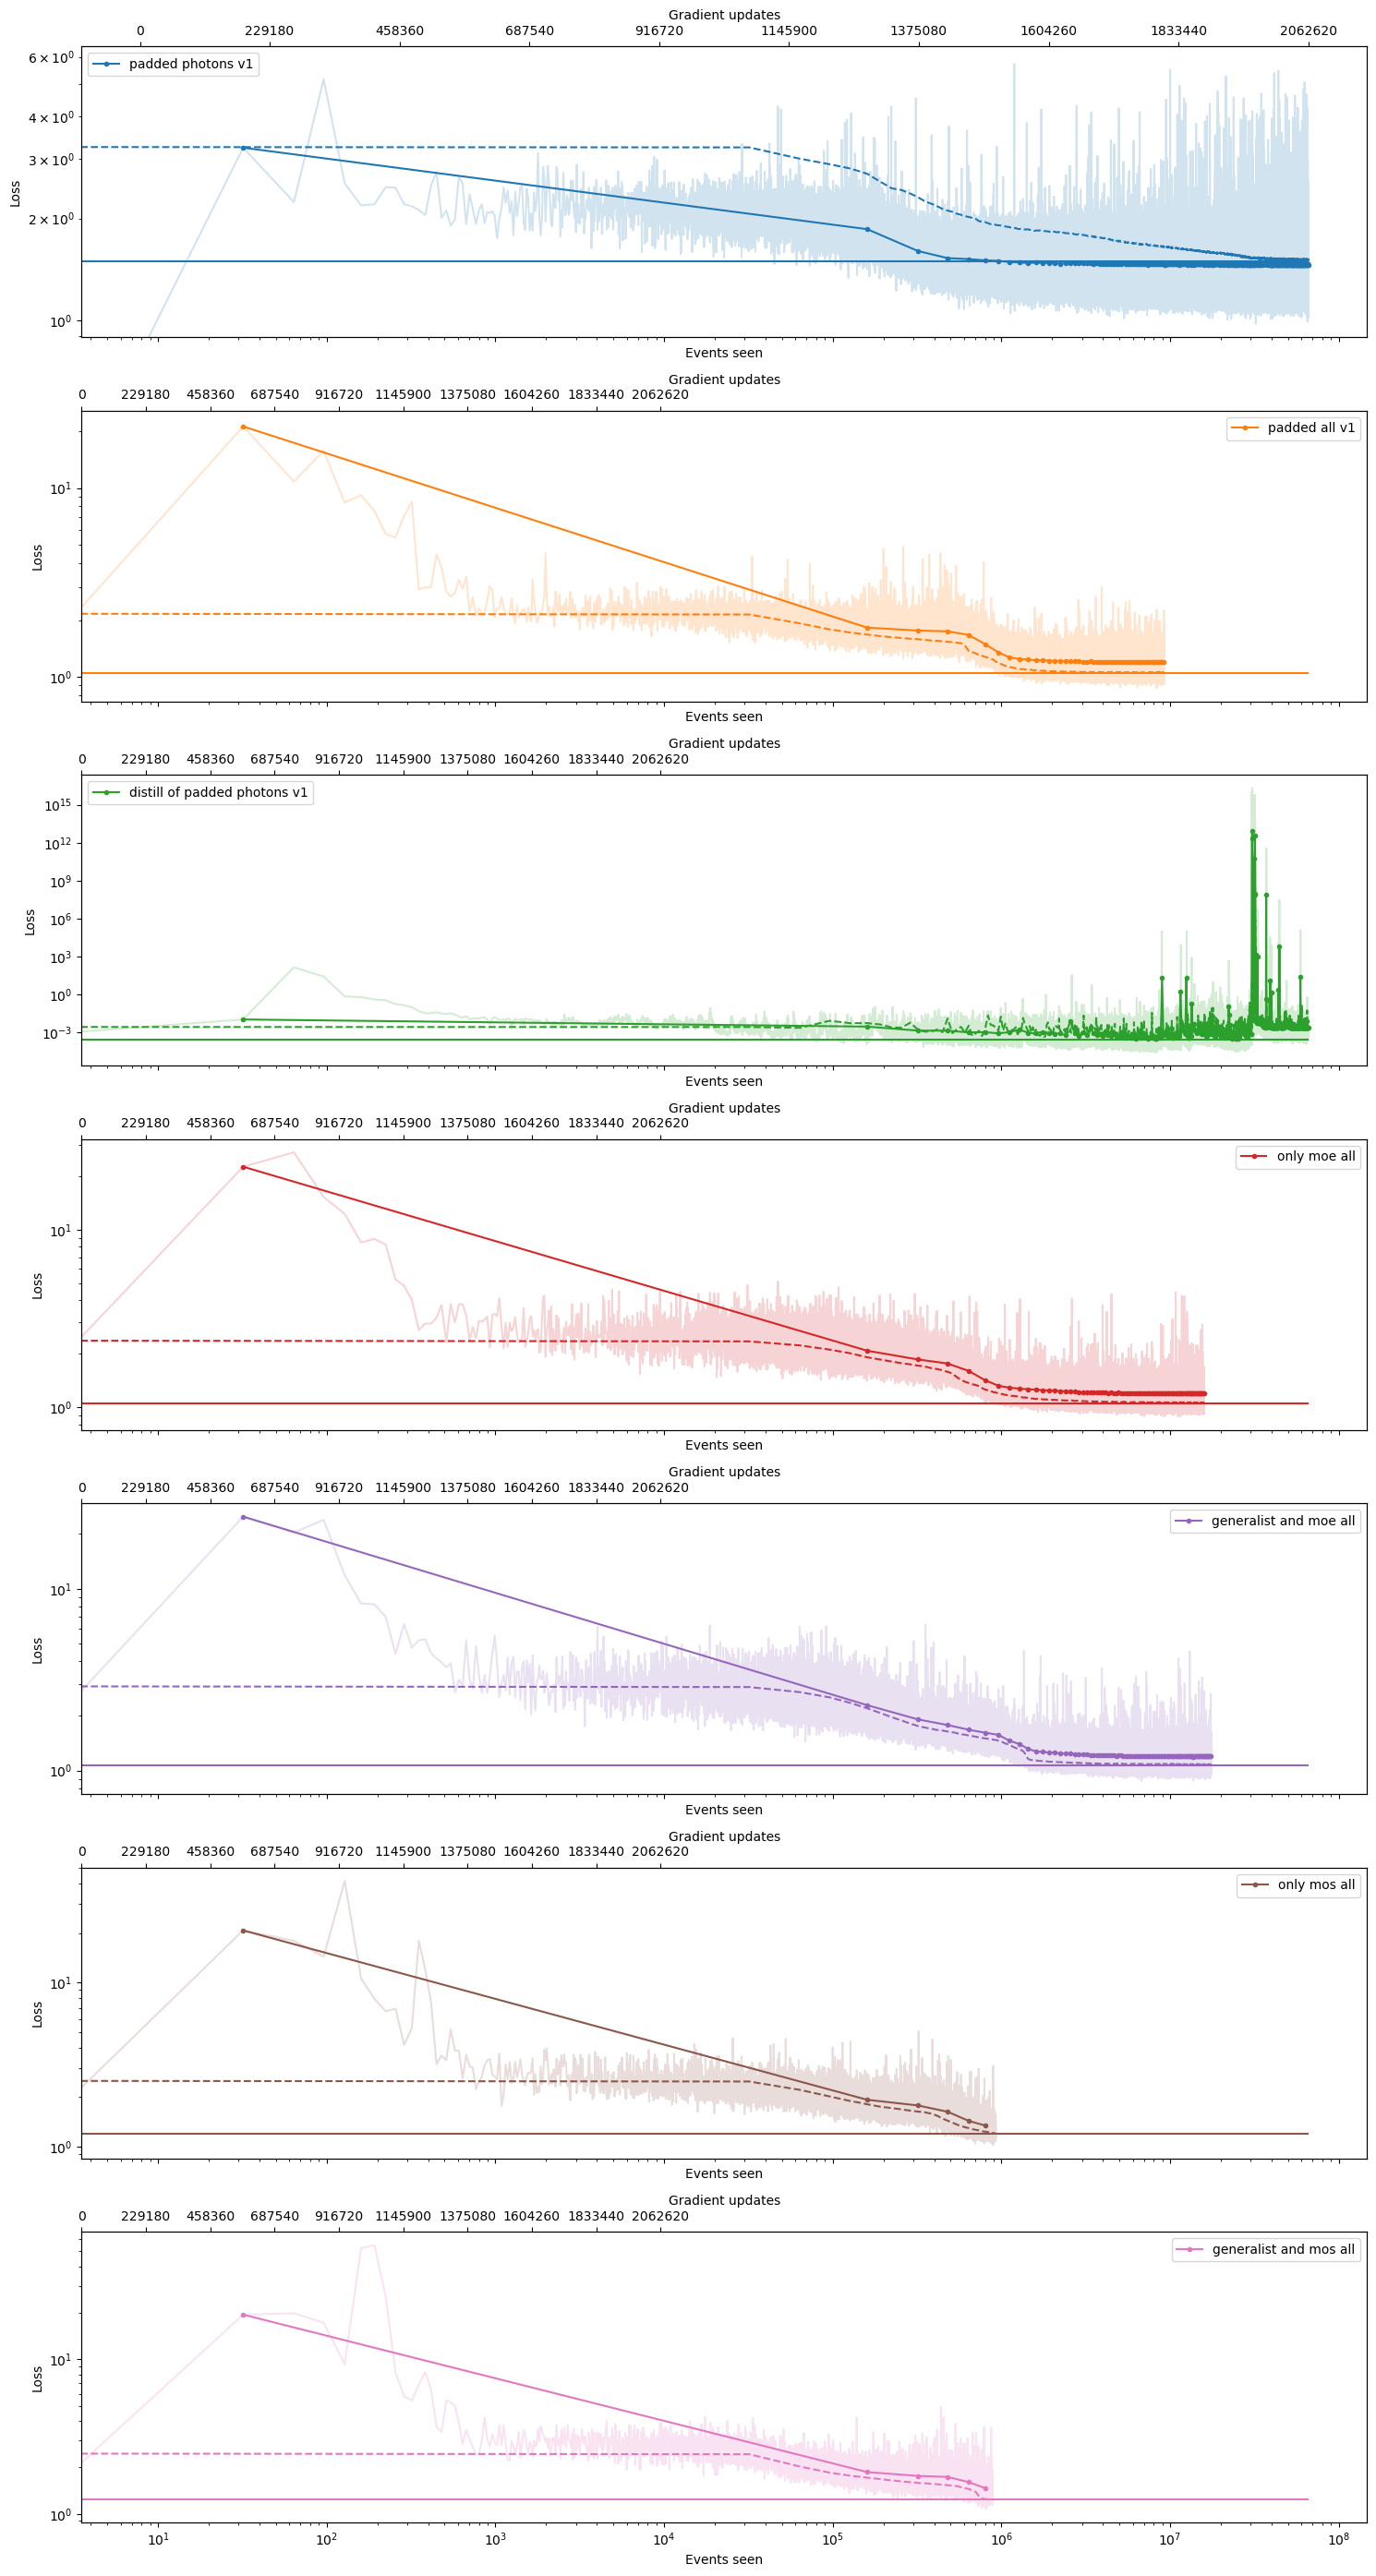

In [45]:
fig, axarr = plt.subplots(len(infos), 1, figsize=(15, 4*len(infos)), sharex=True)
x_name = 'n_events'
y_name = "loss"

longest = trainings[0]

for data in trainings:
    if len(data[x_name]) > len(longest[x_name]):
        longest = data
        
max_x = longest[x_name][-1]

        
for i, info in enumerate(infos):
    y_label = pretty[y_name]
    ax = axarr[i]

    # main axis
    data = trainings[i]
    c = colours[info]
    ax.plot(data[x_name], data[y_name], c=c, alpha=0.2)
    s_xs, s_ys = sparse_average(data[x_name], data[y_name])
    ax.plot(s_xs, s_ys, c=c, label=info, marker='.')
    
    if y_name == "loss":
        val_loss = np.mean(data["val_loss"], axis=1)
        val_n_events = data["val_n_events"]
        ax.plot(val_n_events, val_loss, c=c, ls='--')
        lowest_val_loss = np.min(val_loss)
        ax.hlines(lowest_val_loss, 0, max_x, colors=c)

    ax.semilogy()
    ax.set_xlabel(pretty[x_name])
    ax.set_ylabel(y_label)


    # upper axis
    n_values = len(longest[x_name])
    n_ticks = 10
    value_idxs = np.linspace(0, n_values-1, n_ticks).astype(int)
    positions = [longest[x_name][idx] for idx in value_idxs]
    x_2_name = 'n_updates'
    labels = [longest[x_2_name][idx] for idx in value_idxs]
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())                   # share the bottom's coordinates
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel(pretty[x_2_name])
    ax.legend()
    ax.semilogx()

fig.tight_layout()

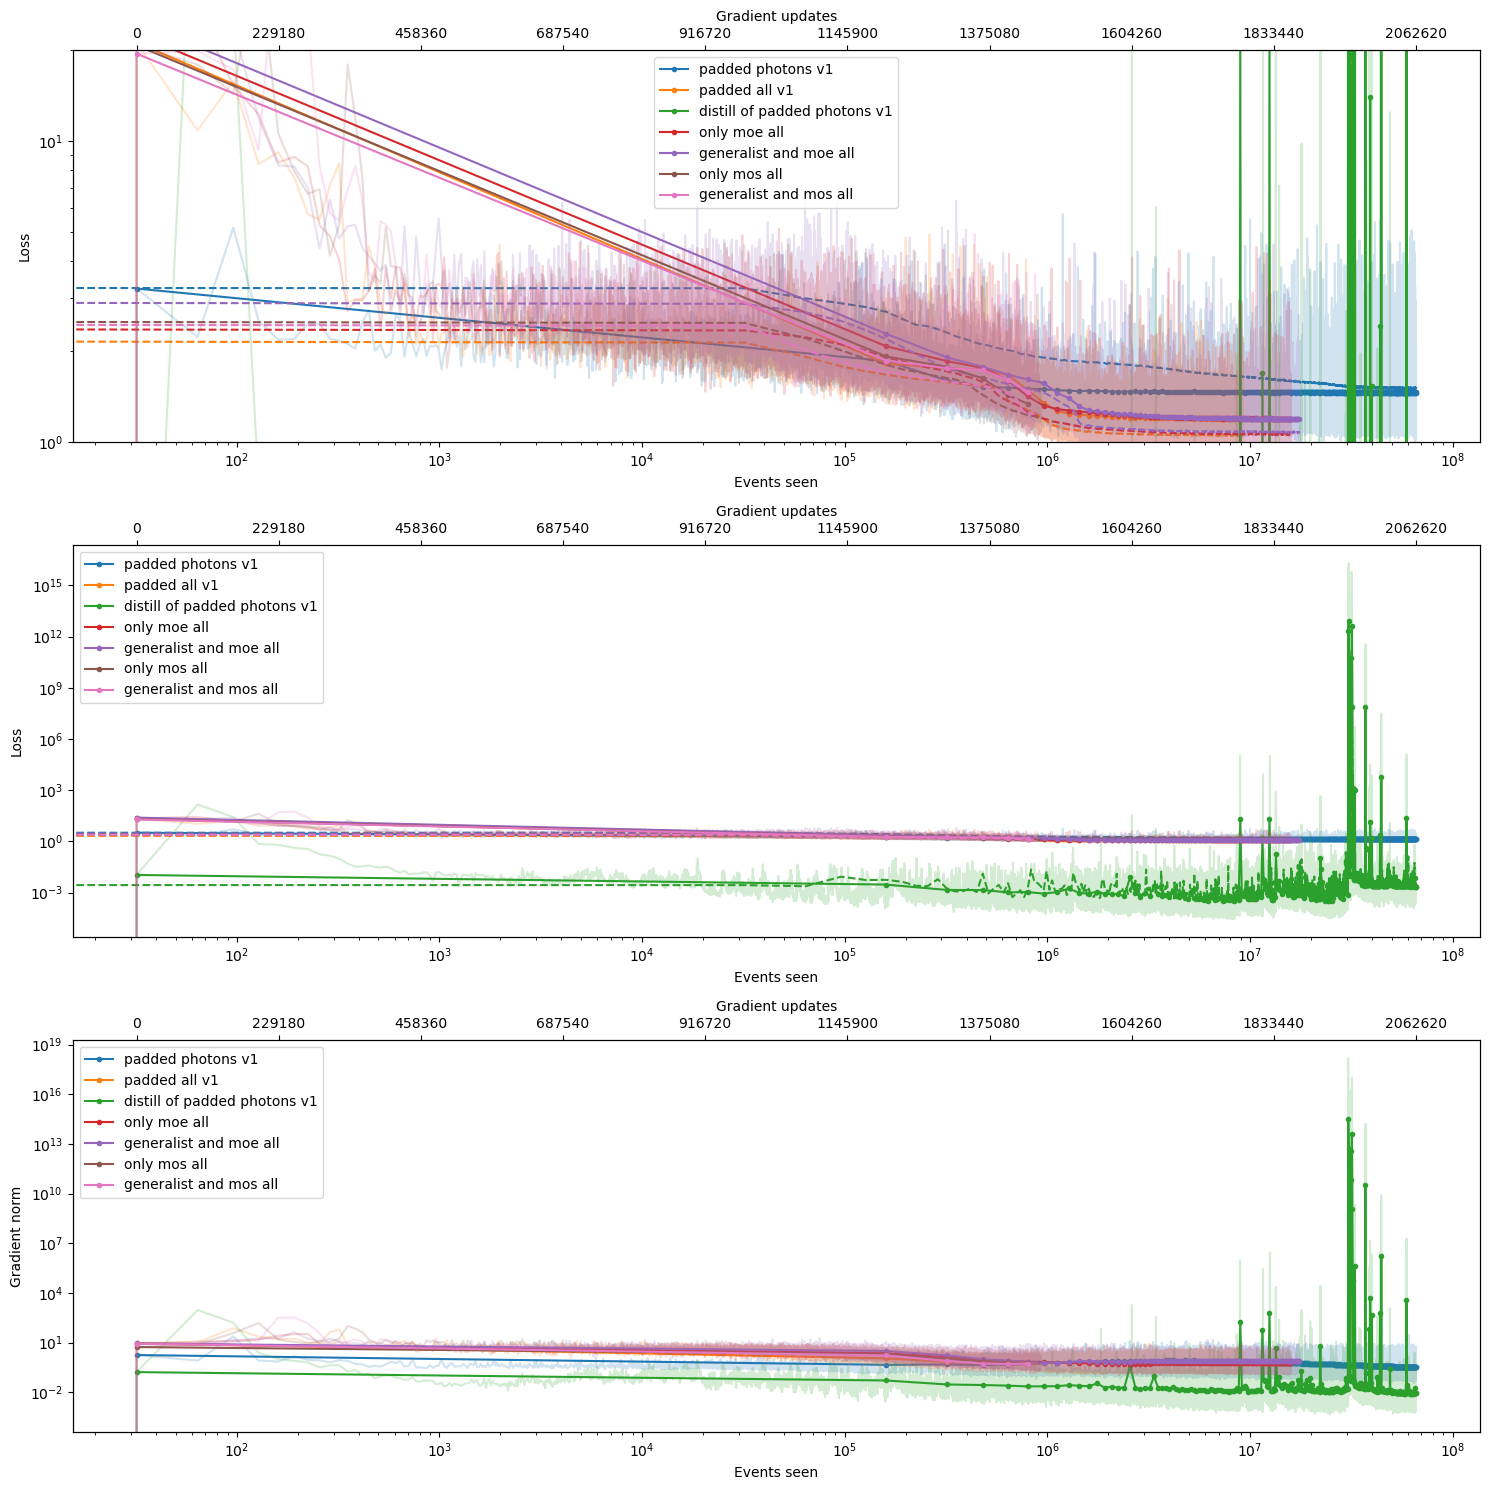

In [46]:
fig, axarr = plt.subplots(3, 1, figsize=(15, 15))
x_name = 'n_events'
y_values = ["loss", "loss", "grad_norm"] #, "ema_decay"]
for i, y_name in enumerate(y_values):
    y_label = pretty[y_name]
    ax = axarr[i]

    # main axis
    longest = trainings[0]
    lowest_val_losses = []
    colour_list = []
    for info, data in zip(infos, trainings):

        c = colours[info]
        colour_list.append(c)
        if len(data[x_name]) > len(longest[x_name]):
            longest = data
        ax.plot(data[x_name], data[y_name], c=c, alpha=0.2)
        s_xs, s_ys = sparse_average(data[x_name], data[y_name])
        ax.plot(s_xs, s_ys, c=c, label=info, marker='.')
        
        if y_name == "loss":
            val_loss = np.mean(data["val_loss"], axis=1)
            val_n_events = data["val_n_events"]
            ax.plot(val_n_events, val_loss, c=c, ls='--')
            lowest_val_losses.append(np.min(val_loss))

    if (i==0) & (y_name == "loss"):
        max_x = longest[x_name][-1]
        #ax.hlines(lowest_val_losses, 0, max_x, colors=colour_list)
        ax.set_ylim(1, 20)
    
    if y_name in ["loss", "grad_norm"]:
        ax.semilogy()
    ax.set_xlabel(pretty[x_name])
    ax.set_ylabel(y_label)


    # upper axis
    n_values = len(longest[x_name])
    n_ticks = 10
    value_idxs = np.linspace(0, n_values-1, n_ticks).astype(int)
    positions = [longest[x_name][idx] for idx in value_idxs]
    x_2_name = 'n_updates'
    labels = [longest[x_2_name][idx] for idx in value_idxs]
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())                   # share the bottom's coordinates
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel(pretty[x_2_name])
    ax.legend()
    ax.semilogx()

fig.tight_layout()